# Tufa Labs ARC3 submission

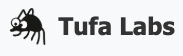

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()

def _retuned_setup_commands():
    """Load the bundled setup commands, lowering vLLM's KV reservation to fit the agent.

    The bundle serves with --max-model-len 65536 while the analyzer caps prompt+completion
    at LOCAL_ANALYZER_CONTEXT_WINDOW (32768). The unused half of every sequence's KV
    reservation is what limits how many of the {concurrency} concurrent games fit in cache.
    We rewrite the constant in place rather than hand-rolling the serve command, because
    inheriting the bundle's serve is the one thing that has reliably worked.
    """
    import re

    raw = (BUNDLE_DIR / "setup_commands.json").read_text()
    commands = json.loads(raw)

    window = re.search(r"ANALYZER_CONTEXT_WINDOW\s*=\s*(\d+)", raw)
    current = re.search(r"VLLM_MAX_MODEL_LEN\s*=\s*(\d+)", raw)
    if not window or not current:
        print("[duck-throughput] WARNING: could not find the context constants; "
              "serving UNCHANGED", flush=True)
        return commands

    target = int(window.group(1)) + 8192
    if target >= int(current.group(1)):
        print(f"[duck-throughput] target {target} not below current "
              f"{current.group(1)}; serving UNCHANGED", flush=True)
        return commands

    retuned, n = re.subn(
        r"VLLM_MAX_MODEL_LEN\s*=\s*\d+",
        f"VLLM_MAX_MODEL_LEN = {target}",
        raw,
    )
    if n != 1:
        print(f"[duck-throughput] WARNING: expected 1 rewrite, made {n}; "
              "serving UNCHANGED", flush=True)
        return commands

    print(f"[duck-throughput] max-model-len {current.group(1)} -> {target} "
          f"(analyzer window {window.group(1)} + 8192 headroom); "
          f"KV reservation cut {100 - 100 * target // int(current.group(1))}%", flush=True)
    return json.loads(retuned)


if TRUE_SUBMISSION:  # serving Qwen needs the eval GPU; the CPU-safe commit skips it
    for command in _retuned_setup_commands():
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# In-memory harness patches. Inlined from submission/_duck_patched/duck_patches.py
# by build_duck_patched.py — edit that file and rebuild, never edit this cell.
#
# The Kaggle source dataset is read-only, so these are monkey-patches. They run
# after the bundle is on sys.path and the benchmark is loaded, before bm.run().
# Model, sampling, concurrency, budgets and the game list are untouched.
# ============================================================================

"""In-memory patches applied to the read-only TAAF duck bundle before `bm.run()`.

The Kaggle dataset that carries the duck harness is read-only, so every fix here is a
monkey-patch installed at import time in the notebook. Each patch is independently
guarded: if the upstream shape it expects is missing, that patch reports FAIL and the
others still apply. Nothing here changes the model, sampling, concurrency or budgets.

PATCH 1 — ACTION7 round trip (BUG FIX).
    `inference.agent.action_names.ENGINE_TO_MODEL_ACTION` maps ACTION1..6 + RESET only.
    `to_model_action("ACTION7")` passes the name through to the model, but
    `to_engine_action("ACTION7")` returns None, so solver.py's action parser rejects it
    with "Unknown action at index N". The model is offered a legal action it can never
    execute. 6 of the 25 public games use ACTION7 (ar25, bp35, lf52, sb26, sk48, su15).

PATCH 2 — animation metadata.
    `taaf.game.GameState.animation_frames` already exposes the intermediate frames of a
    multi-frame action, but only the final frame ever reaches the model. This adds a few
    scalar fields per action describing what moved during the animation. No images, no
    raw frames — roughly 20-40 tokens per action of causal signal.

NOT PATCHED — RESET restriction.
    The public fork this work draws on restricts RESET to GAME_OVER. Our bundle already
    does the equivalent, more thoroughly: `solver._engine_action_names` strips RESET from
    the model's choices unconditionally (solver.py:116-117) and `_execute_auto_reset()`
    fires on GAME_OVER (solver.py:278-282). No change needed; verified by
    `verify_reset_already_handled()` below.
"""
from __future__ import annotations

from typing import Any

# Engine action ids that count as real actions (RESET is id 0 and is scored differently).
_ACTION7 = "ACTION7"


def patch_action7() -> str:
    """Make ACTION7 survive the model<->engine name round trip. Returns a status line."""
    from inference.agent import action_names as an

    if _ACTION7 in an.ENGINE_TO_MODEL_ACTION:
        return "patch1 action7: SKIP (already mapped)"

    # ACTION7's meaning is not fixed across games, so it has no friendly label like
    # UP/DOWN/MOUSE. Map it to itself: the model sees "ACTION7" and the engine gets
    # "ACTION7" back.
    an.ENGINE_TO_MODEL_ACTION[_ACTION7] = _ACTION7
    an.MODEL_TO_ENGINE_ACTION.clear()
    an.MODEL_TO_ENGINE_ACTION.update(
        {value: key for key, value in an.ENGINE_TO_MODEL_ACTION.items()}
    )

    if an.to_engine_action(an.to_model_action(_ACTION7)) != _ACTION7:
        raise RuntimeError("patch1 action7: round trip still broken after patch")
    return "patch1 action7: OK"


def patch_animation_producer() -> str:
    """Attach the animation summary to the payload `_execute_action` returns.

    `_compact_action_result` (patch 2b) only forwards these keys; this is what creates
    them. Wrapping the method rather than reimplementing it keeps us insulated from
    upstream changes to the payload's other fields.
    """
    from inference.framework import solver

    session = getattr(solver, "_HarnessGameSession", None)
    if session is None or not hasattr(session, "_execute_action"):
        return "patch2a animation-producer: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session._execute_action, "_animation_patched", False):
        return "patch2a animation-producer: SKIP (already applied)"

    original = session._execute_action

    def _execute_action(self: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original(self, *args, **kwargs)
        if isinstance(payload, dict):
            try:
                payload.update(summarize_animation(self.game.current_state))
            except Exception:
                pass  # never let telemetry break an action
        return payload

    _execute_action._animation_patched = True  # type: ignore[attr-defined]
    session._execute_action = _execute_action
    return "patch2a animation-producer: OK"


def patch_animation_metadata() -> str:
    """Forward the animation summary through the compaction the model actually sees."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_compact_action_result"):
        return "patch2b animation-forward: FAIL (ToolAgent._compact_action_result not found)"
    if getattr(agent_cls._compact_action_result, "_animation_patched", False):
        return "patch2b animation-forward: SKIP (already applied)"

    original = agent_cls._compact_action_result

    def _compact_action_result(self: Any, payload: dict[str, Any]) -> dict[str, Any]:
        compact = original(self, payload)
        for key in _ANIMATION_KEYS:
            if key in payload:
                compact[key] = payload[key]
        return compact

    _compact_action_result._animation_patched = True  # type: ignore[attr-defined]
    agent_cls._compact_action_result = _compact_action_result
    return "patch2b animation-forward: OK"


_ANIMATION_KEYS = (
    "animation_frame_count",
    "animation_changed",
    "animation_only_changed",
    "animation_changed_cell_count",
    "animation_changed_bbox",
)


def summarize_animation(state: Any) -> dict[str, Any]:
    """Describe the animation of a just-executed action as a handful of scalars.

    `state` is a taaf GameState. Returns {} when the action produced no animation, so
    single-frame actions cost zero extra tokens.
    """
    try:
        animation = list(state.animation_frames)
    except Exception:
        return {}
    if not animation:
        return {}

    final = _frame_rows(state.frame)
    changed_cells: list[tuple[int, int]] = []
    only_in_animation = False

    for frame in animation:
        rows = _frame_rows(frame)
        for y, (arow, frow) in enumerate(zip(rows, final)):
            for x, (avalue, fvalue) in enumerate(zip(arow, frow)):
                if avalue != fvalue:
                    changed_cells.append((x, y))
                    only_in_animation = True

    out: dict[str, Any] = {
        "animation_frame_count": len(animation),
        "animation_changed": bool(changed_cells),
        # True when the animation showed motion that is NOT visible in the final frame —
        # i.e. something moved and returned, or moved through. This is the signal the
        # model cannot otherwise recover.
        "animation_only_changed": only_in_animation,
        "animation_changed_cell_count": len(set(changed_cells)),
    }
    if changed_cells:
        xs = [x for x, _ in changed_cells]
        ys = [y for _, y in changed_cells]
        out["animation_changed_bbox"] = [min(xs), min(ys), max(xs), max(ys)]
    return out


def _frame_rows(frame: Any) -> list[list[int]]:
    data = getattr(frame, "data", frame)
    return [list(row) for row in data]


def verify_reset_already_handled() -> str:
    """Confirm our bundle already restricts RESET, so patch 3 is genuinely unnecessary."""
    import inspect

    from inference.framework import solver

    src = inspect.getsource(solver._engine_action_names)
    strips_reset = 'if name == "RESET"' in src and "continue" in src
    auto_resets = hasattr(solver._HarnessGameSession, "_execute_auto_reset")
    if strips_reset and auto_resets:
        return "patch3 reset: NOT NEEDED (RESET stripped from choices + auto-reset on GAME_OVER)"
    return (
        f"patch3 reset: REVIEW (strips_reset={strips_reset}, auto_resets={auto_resets}) "
        "— upstream changed, re-check whether RESET must be restricted"
    )


def apply_all(verbose: bool = True) -> list[str]:
    """Apply every patch. Each is independent; one failing does not block the others."""
    results = []
    for fn in (
        patch_action7,
        patch_animation_producer,
        patch_animation_metadata,
        verify_reset_already_handled,
    ):
        try:
            results.append(fn())
        except Exception as exc:  # noqa: BLE001 - a broken patch must not kill the run
            results.append(f"{fn.__name__}: FAIL ({exc})")
    if verbose:
        for line in results:
            print(f"[duck-patch] {line}", flush=True)
    return results


_patch_results = apply_all()
if any("FAIL" in line for line in _patch_results):
    # Loud but non-fatal: a failed patch means upstream moved, and we want that in
    # the log rather than a silently unpatched scored run.
    print("[duck-patch] WARNING: at least one patch did not apply", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()

    # --- adaptive per-game budget -------------------------------------------------
    # The bundle ships max_runtime_s_per_game=7920 with concurrency=28, which exactly
    # fills a 9h budget IF the eval set is 110 games (110/28 = 4 waves x 7920 = 31680s).
    # Two things are unresolved: the ARC-AGI-3 technical report says the competition set
    # is 55 fully-private environments (which would be 2 waves = 4.4h, leaving ~4.6h of
    # GPU idle), and the total notebook cap has four conflicting public figures.
    #
    # Rather than bet on either number, derive the budget from what the gateway actually
    # serves. The rule is deliberately one-directional: RAISE the per-game budget when
    # there are fewer waves than the shipped tuning assumed, never lower it. So a
    # 110-game set is byte-for-byte the current behaviour, and a 55-game set claims the
    # idle half. Anything unexpected leaves the budget untouched.
    try:
        _n_games = len(bm.games)
        _conc = int(getattr(bm.solver, "concurrency", 0) or 0)
        _total = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
        _current = float(getattr(bm.solver, "max_runtime_s_per_game", 0.0) or 0.0)
        if _n_games > 0 and _conc > 0 and _total > 0 and _current > 0:
            _waves = -(-_n_games // _conc)  # ceil
            _elapsed = time.time() - NOTEBOOK_START_EPOCH  # setup + vLLM serve
            # 0.9 leaves room for the solver to drain and the scorecard to close.
            _per_game = (_total - _elapsed) * 0.9 / _waves
            if _per_game > _current:
                bm.solver.max_runtime_s_per_game = _per_game
                print(f"[duck-adaptive] {_n_games} games / concurrency {_conc} "
                      f"= {_waves} wave(s); per-game budget {_current:.0f}s -> "
                      f"{_per_game:.0f}s ({_elapsed:.0f}s already spent on setup)",
                      flush=True)
            else:
                print(f"[duck-adaptive] {_n_games} games / {_conc} = {_waves} wave(s); "
                      f"computed {_per_game:.0f}s is not above the shipped "
                      f"{_current:.0f}s — budget UNCHANGED", flush=True)
        else:
            print("[duck-adaptive] missing a knob "
                  f"(games={_n_games}, concurrency={_conc}, total={_total}, "
                  f"current={_current}) — budget UNCHANGED", flush=True)
    except Exception as _exc:
        print(f"[duck-adaptive] WARNING: {_exc!r} — budget UNCHANGED", flush=True)
    # ------------------------------------------------------------------------------
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if TRUE_SUBMISSION:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    else:
        import pandas as pd
        pd.DataFrame([["1_0", "1", True, 1]],
                     columns=["row_id", "game_id", "end_of_game", "score"]
                     ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
        print("[duck] commit: CPU-safe landing; scored rerun runs the patched duck", flush=True)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")